In [1]:
import torch
import torch.nn as nn
from torch import Tensor
import torch.optim as optim
from torch.utils.data import Dataset,DataLoader,SubsetRandomSampler,ConcatDataset
import torch.nn.functional as F

In [2]:
import sys
import os
sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))

from model import SeqNN

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print(device)

cuda:0


In [4]:
# Load the entire model (architecture + weights)
model = torch.load("/home1/smaruj/pytorch_akita/model.pth")

/tmp/SLURM_200558/ipykernel_1965404/3921338739.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load("/home1/smaruj/pytorch_akita/model.pth")


In [5]:
model = model.to(device)

In [6]:
# Set the model to evaluation mode (important for inference)
model.eval()

SeqNN(
  (stochastic_reverse_complement): StochasticReverseComplement()
  (stochastic_shift): StochasticShift()
  (re_lu): ReLU()
  (conv_block_1): ConvBlock(
    (conv): Conv1d(4, 96, kernel_size=(11,), stride=(1,), padding=(5,), bias=False)
    (batch_norm): BatchNorm1d(96, eps=0.001, momentum=0.9265, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_tower): ConvTower(
    (conv_tower): Sequential(
      (0): ReLU()
      (1): Conv1d(96, 96, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (2): BatchNorm1d(96, eps=0.001, momentum=0.9265, affine=True, track_running_stats=True)
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): ReLU()
      (5): Conv1d(96, 96, kernel_size=(5,), stride=(1,), padding=(2,), bias=False)
      (6): BatchNorm1d(96, eps=0.001, momentum=0.9265, affine=True, track_running_stats=True)
      (7): MaxPool1d(kernel_size

In [7]:
from torchinfo import summary

summary(model, input_size=(2, 4, 1048576), col_names=["output_size", "num_params"])

Layer (type:depth-idx)                   Output Shape              Param #
SeqNN                                    [2, 5, 99681]             --
├─StochasticReverseComplement: 1-1       [2, 4, 1048576]           --
├─StochasticShift: 1-2                   [2, 4, 1048576]           --
├─ReLU: 1-3                              [2, 4, 1048576]           --
├─ConvBlock: 1-4                         [2, 96, 524288]           --
│    └─Conv1d: 2-1                       [2, 96, 1048576]          4,224
│    └─BatchNorm1d: 2-2                  [2, 96, 1048576]          192
│    └─MaxPool1d: 2-3                    [2, 96, 524288]           --
├─ConvTower: 1-5                         [2, 96, 512]              --
│    └─Sequential: 2-4                   [2, 96, 512]              --
│    │    └─ReLU: 3-1                    [2, 96, 524288]           --
│    │    └─Conv1d: 3-2                  [2, 96, 524288]           46,080
│    │    └─BatchNorm1d: 3-3             [2, 96, 524288]           192
│    │

In [8]:
from pyfaidx import Fasta

In [9]:
fasta_file = "/project/fudenber_735/genomes/hg38/hg38.fa"
genome = Fasta(fasta_file)

region = "chr12"
start = 115163136
end = 116211712

# region = "chr11"
# start = 75429888
# end = 76478464

# region = "chr15"
# start = 63281152
# end = 64329728

In [10]:
sequence = genome[region][start:end]

# sequence = "A" * 1048576

In [11]:
genome.close()

In [12]:
del genome

In [13]:
import numpy as np

In [14]:
def one_hot_encode_sequence(sequence_obj):
    # Convert pyfaidx.Sequence object to string
    sequence = str(sequence_obj).upper()

    # Define the mapping from bases to integers
    base_to_int = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

    # Step 1: Encode the sequence to integers
    encoded_sequence = np.array([base_to_int[base] for base in sequence])

    # Step 2: One-hot encode the sequence
    one_hot_encoded = np.zeros((4, len(encoded_sequence)), dtype=np.float32)
    one_hot_encoded[encoded_sequence, np.arange(len(encoded_sequence))] = 1

    # Step 3: Expand the dimensions to [1, 4, sequence_length]
    input_sequence = np.expand_dims(one_hot_encoded, axis=0)

    return input_sequence

In [15]:
X = one_hot_encode_sequence(sequence)

In [16]:
del sequence

In [17]:
# Convert the NumPy array to a PyTorch tensor
X_torch = torch.tensor(X)

# Now you can move the tensor to the desired device (e.g., GPU or CPU)
# X = X_torch.to(device)
X = X_torch.to("cuda:0")

In [18]:
model.eval()
with torch.no_grad():
    y = model(X, training=False)

In [19]:
del X_torch

In [20]:
# Helper function to set diagonal elements to a specific value
def set_diag(matrix, value, k):
    # Explicitly set the diagonal to 'value' (in this case, np.nan) for each k
    rows, cols = matrix.shape
    for i in range(rows):
        if 0 <= i + k < cols:
            matrix[i, i + k] = value

def from_upper_triu(vector_repr, matrix_len, num_diags):
    # Ensure vector_repr is a NumPy array (if it's a PyTorch tensor, convert it)
    if isinstance(vector_repr, torch.Tensor):
        vector_repr = vector_repr.detach().flatten().cpu().numpy()  # Flatten and convert to NumPy array

    # Initialize a zero matrix of shape (matrix_len, matrix_len)
    z = np.zeros((matrix_len, matrix_len))

    # Get the indices for the upper triangular matrix
    triu_tup = np.triu_indices(matrix_len, num_diags)

    # Assign the values from the vector_repr to the upper triangular part of the matrix
    z[triu_tup] = vector_repr

    # Set the diagonals specified by num_diags to np.nan
    for i in range(-num_diags + 1, num_diags):
        set_diag(z, np.nan, i)

    # Ensure the matrix is symmetric
    return z + z.T

In [21]:
target0 = y[:,0,:]

In [22]:
matrix = from_upper_triu(target0, matrix_len=448, num_diags=2)

<Figure size 800x800 with 0 Axes>

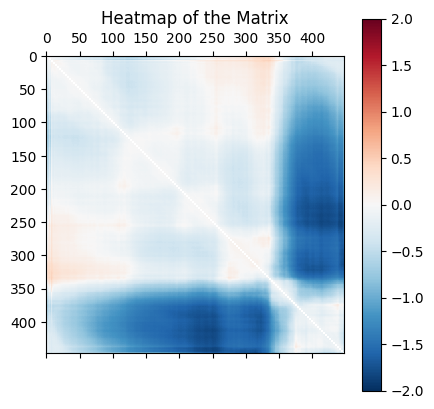

In [23]:
import matplotlib.pyplot as plt

# Plot the matrix
plt.figure(figsize=(8, 8))
plt.matshow(matrix.astype(np.float16), cmap='RdBu_r', vmin=-2, vmax=2)
plt.colorbar()
plt.title('Heatmap of the Matrix')
plt.show()

In [24]:
with open('strong_boundary.npy', 'rb') as f:
    strong_boundary = np.load(f)

In [25]:
strong_boundary = strong_boundary * 3

In [26]:
strong_boundary = strong_boundary[32:-32,32:-32]

<Figure size 800x800 with 0 Axes>

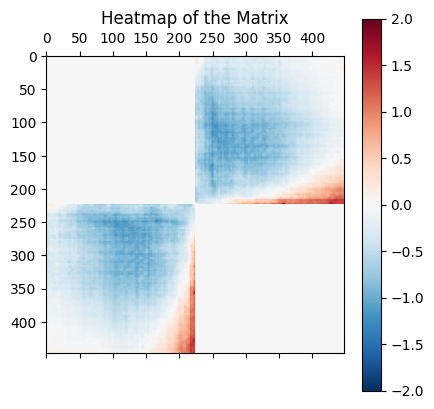

In [27]:
plt.figure(figsize=(8, 8))
plt.matshow(strong_boundary.astype(np.float16), cmap='RdBu_r', vmin=-2, vmax=2)
plt.colorbar()
plt.title('Heatmap of the Matrix')
plt.show()

In [28]:
def upper_triangular_to_vector_skip_two_diagonals(matrix):
    """
    Extracts the upper triangular part of a square matrix (excluding the first two diagonals) 
    and transforms it into a vector.
    
    Parameters:
        matrix (np.ndarray): A 2D numpy matrix of shape (448, 448).
        
    Returns:
        np.ndarray: A 1D array containing the upper triangular elements (excluding the first two diagonals).
    """
    if matrix.shape != (448, 448):
        raise ValueError("Input matrix must be of shape (448, 448).")
    
    # Extract the upper triangular part excluding the first two diagonals
    upper_triangular_vector = matrix[np.triu_indices(448, k=2)]
    
    return upper_triangular_vector

In [29]:
strong_up_triu = upper_triangular_to_vector_skip_two_diagonals(strong_boundary)

In [30]:
y_cpu = y.cpu()

In [31]:
y_bar_cpu = y_cpu.clone().detach()

In [32]:
y_bar_cpu[:,0,:] = y_cpu[:,0,:] + strong_up_triu

/tmp/SLURM_200558/ipykernel_1965404/3970045193.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_bar_cpu[:,0,:] = y_cpu[:,0,:] + strong_up_triu


In [33]:
y_bar_cpu[:,1,:] = y_cpu[:,1,:] + strong_up_triu
y_bar_cpu[:,2,:] = y_cpu[:,2,:] + strong_up_triu
y_bar_cpu[:,3,:] = y_cpu[:,3,:] + strong_up_triu
y_bar_cpu[:,4,:] = y_cpu[:,4,:] + strong_up_triu

/tmp/SLURM_200558/ipykernel_1965404/1317633215.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_bar_cpu[:,1,:] = y_cpu[:,1,:] + strong_up_triu
/tmp/SLURM_200558/ipykernel_1965404/1317633215.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_bar_cpu[:,2,:] = y_cpu[:,2,:] + strong_up_triu
/tmp/SLURM_200558/ipykernel_1965404/1317633215.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_bar_cpu[:,3,:] = y_cpu[:,3,:] + strong_up_triu
/tmp/SLURM_200558/ipykernel_1965404/1317633215.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_bar_cpu[:,4,:] = y_cpu[:,4,:] + strong_up_triu


In [34]:
goal = matrix + strong_boundary

<Figure size 800x800 with 0 Axes>

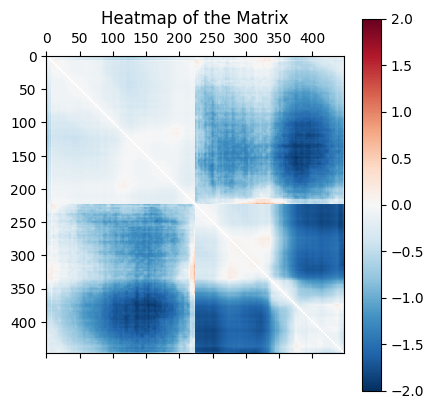

In [35]:
plt.figure(figsize=(8, 8))
plt.matshow(goal.astype(np.float16), cmap='RdBu_r', vmin=-2, vmax=2)
plt.colorbar()
plt.title('Heatmap of the Matrix')
plt.show()

In [36]:
# to ensure the local, forked ledidi is used
# not the one installed using pip

import sys
sys.path.insert(0, "/home1/smaruj/ledidi")  # Add the directory where "ledidi" is located
from ledidi import Ledidi

In [37]:
y_bar = y_bar_cpu.to("cuda:0")

In [38]:
del y_cpu

In [39]:
X.shape, y_bar.shape

(torch.Size([1, 4, 1048576]), torch.Size([1, 5, 99681]))

In [40]:
X.device, y_bar.device

(device(type='cuda', index=0), device(type='cuda', index=0))

In [ ]:
# mask_vector = torch.ones((1048576), dtype=torch.bool)
# mask_vector[523288:525288] = 0 # +-1kb

In [41]:
wrapper = Ledidi(model, verbose=True, batch_size=2,
                 input_loss=torch.nn.L1Loss(reduction='sum'), 
                 output_loss=torch.nn.L1Loss(reduction='sum'),
                 max_iter=20000,
                 early_stopping_iter=1000,
                #  input_mask = mask_vector,  
                 ).cuda()

In [42]:
x_bar = wrapper.fit_transform(X, y_bar)

iter=I	input_loss=0.0	output_loss=1.253e+05	total_loss=1.253e+05	time=0.0
forward time = 0.013097524642944336
pred time = 0.034540653228759766
backward time = 0.09160804748535156
iter=F	input_loss= 0.0	output_loss=1.253e+05	total_loss=1.253e+05	time=0.1592


In [ ]:
x_bar.shape

In [ ]:
# number of edits
(x_bar[0] != X).sum() // 2

In [ ]:
(x_bar[1] != X).sum() // 2

In [ ]:
model.eval()
with torch.no_grad():
    pred = model(x_bar, training=False)

In [ ]:
pred.shape

In [ ]:
target_pred = pred[0,0,:]

In [ ]:
pred_matrix = from_upper_triu(target_pred, matrix_len=448, num_diags=2)

In [ ]:
# Plot the matrix
plt.figure(figsize=(8, 8))
plt.matshow(pred_matrix.astype(np.float16), cmap='RdBu_r', vmin=-2, vmax=2)
plt.colorbar()
plt.title('Heatmap of the Matrix')
plt.show()